In [2]:
import os
import numpy as np
import flopy
import math
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import flopy.utils.postprocessing as pp
from flopy.utils import CellBudgetFile, HeadFile
import matplotlib.colors as mcolors
from unicodedata import name

In [4]:
MODFLOW_PATH = "../binaries/MODFLOW6/windows"

flopy.utils.get_modflow(MODFLOW_PATH)

fetched release '23.0' info from MODFLOW-ORG/executables
using previous download 'C:\Users\kaden.mcculloch\Downloads\modflow_executables-23.0-win64.zip' (use 'force=True' to re-download)
extracting 25 files to 'C:\Python\Personal\kfm-ms\codes\binaries\MODFLOW6\windows'
crt.exe (1.3.1)         mfnwt.exe (1.3.0)       sutra.exe (4.0)
gridgen.exe (1.0.02)    mfnwtdbl.exe (1.3.0)    swtv4.exe (4.00.05)
libmf6.dll (6.6.3)      mfusg.exe (1.5)         triangle.exe (1.6)
mf2000.exe (1.19.01)    mfusgdbl.exe (1.5)      vs2dt.exe (3.3)
mf2005.exe (1.12.00)    mfusg_gsi.exe (2.5.0)   zbud6.exe (6.6.3)
mf2005dbl.exe (1.12.00) mp6.exe (6.0.1)         zonbud3.exe (3.01)
mf6.exe (6.6.3)         mp7.exe (7.2.001)       zonbudusg.exe (1.5)
mflgr.exe (2.0.0)       mt3dms.exe (5.3.0)
mflgrdbl.exe (2.0.0)    mt3dusgs.exe (1.1.0)
updated flopy metadata file: 'C:\Users\kaden.mcculloch\AppData\Local\flopy\get_modflow.json'


In [ ]:
####################
### set up paths ###
####################

notebook_dir = os.getcwd()
mf6_exe = os.path.join(notebook_dir, "..", "binaries", "MODFLOW6", "windows", "mf6.exe")

workspace = "mf6-com-1"
if not os.path.exists(workspace):
    os.makedirs(workspace)

################################
### random domain generation ###
################################

cell_dim = int(np.random.uniform(1.0, 5.0)) # square cells between 1.0 and 5.0 units
target_lx = int(np.random.uniform(50, 150)) # target domain size between 50-150 units in x
target_ly = int(np.random.uniform(50, 150)) # target domain size between 50-150 units in y

nlay = 1 # number of layers
top = 0.0 # top elevation of the single layer
botm = [-10.0] # bottom elevation of the single layer
ncol, nrow = int(target_lx / cell_dim), int(target_ly / cell_dim) # number of columns and rows
lx, ly = float(ncol * cell_dim), float(nrow * cell_dim) # adjust domain size to be an integer number of cells

# calculate cell edges and centers for later use
x_centres = np.linspace(-lx/2 + cell_dim/2, lx/2 - cell_dim/2, ncol)
y_centres = np.linspace(ly/2 - cell_dim/2, -ly/2 + cell_dim/2, nrow)

centre_r = nrow // 2
centre_c = ncol // 2

dt = 7.0 # stress period length in days
nper = 52 # number of stress periods (e.g. 52 weeks in a year)
time_steps = np.arange(dt, (nper * dt) + dt, dt) # time steps for plotting, from dt to nper*dt with step of dt

########################################
### define simulation setup function ###
########################################

def setup_sim(name, wel_data):

    # create the simulation and model objects
    sim = flopy.mf6.MFSimulation(sim_name=name, exe_name=mf6_exe, sim_ws=workspace)
    flopy.mf6.ModflowTdis(sim, nper=nper, perioddata=[(dt, 1, 1.0)]*nper)

    # define the solver with robust settings for convergence
    ims = flopy.mf6.ModflowIms(
        sim,
        pname="ims",
        complexity="MODERATE",
        outer_maximum=500,
        inner_maximum=100,
        outer_dvclose=1e-4,
        inner_dvclose=1e-5,
        linear_acceleration="BICGSTAB"
    )

    # register the solver with the simulation
    sim.register_ims_package(ims, list(sim.model_names))
    
    # save_flows=True at the model level needed for ZONEBUDGET
    gwf = flopy.mf6.ModflowGwf(sim, modelname=name, save_flows=True)
    
    flopy.mf6.ModflowGwfdis(gwf, nlay=nlay, nrow=nrow, ncol=ncol, top=top, botm=botm,
                            delr=cell_dim, delc=cell_dim, 
                            xorigin=-lx/2, yorigin=-ly/2)
        
    # save_flows=True at the model level needed for ZONEBUDGET
    flopy.mf6.ModflowGwfnpf(gwf, k=1e-3, icelltype=0, save_flows=True) 
    flopy.mf6.ModflowGwfsto(gwf, ss=1e-5, transient=True, save_flows=True)
    flopy.mf6.ModflowGwfic(gwf, strt=0.0)
    
    # save_flows=True at the model level needed for ZONEBUDGET
    flopy.mf6.ModflowGwfwel(gwf, stress_period_data=wel_data, save_flows=True)
    
    # added budget_filerecord and "BUDGET" to saverecord
    flopy.mf6.ModflowGwfoc(gwf, 
                            head_filerecord=f"{name}.hds", 
                            budget_filerecord=f"{name}.cbc",
                            saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")])
    return sim, gwf

#################################
### compliance zone and wells ###
#################################

# geometry and coordinate snapping logic using a dummy model to access the grid object
_, dummy_gwf = setup_sim("dummy", {})
grid = dummy_gwf.modelgrid
xc, yc = grid.xcellcenters, grid.ycellcenters

# physical parameters for compliance zone and no-go zone
comp_padding = 0.75
nogo_padding = 0.2
comp_hw, comp_hh = (lx / 2) * comp_padding, (ly / 2) * comp_padding
nogo_hw, nogo_hh = comp_hw * nogo_padding, comp_hh * nogo_padding

# get bounding row/column indices
r_min, c_min = grid.intersect(-comp_hw, comp_hh)
r_max, c_max = grid.intersect(comp_hw, -comp_hh)
r_start, r_end = sorted([r_min, r_max])
c_start, c_end = sorted([c_min, c_max])

# generate perimeter CP cells for flux monitoring
cp_cells = []
for c in range(c_start, c_end + 1):
    cp_cells.extend([(r_start, c), (r_end, c)]) # top/bottom
for r in range(r_start + 1, r_end):
    cp_cells.extend([(r, c_start), (r, c_end)]) # left/right

# generate a centre well
centre_well_x = x_centres[centre_c]
centre_well_y = y_centres[centre_r]

# generate random wells within the compliance zone but outside the no-go zone
# ensure they are snapped to cell centres and not duplicated
n_wells = 3 
wells = []

while len(wells) < n_wells:
    wx, wy = np.random.uniform(-lx/2, lx/2), np.random.uniform(-ly/2, ly/2)
    
    # check if inside the compliance zone
    is_in_compliance = (-comp_hw < wx < comp_hw) and (-comp_hh < wy < comp_hh)
    
    # check if outside the no-go zone
    is_in_nogo = (-nogo_hw < wx < nogo_hw) and (-nogo_hh < wy < nogo_hh)
    
    if is_in_compliance and not is_in_nogo:
        r, c = grid.intersect(wx, wy)
        if (r, c) not in [(w['r'], w['c']) for w in wells]:
            wells.append({
                'r': r, 
                'c': c, 
                'Q': np.random.uniform(0.001, 5, nper)
            })

################
### analysis ###
################

# run the random target scenario
wel_spd_r = {p: [((0, w['r'], w['c']), -w['Q'][p]) for w in wells] for p in range(nper)}
sim_r, _ = setup_sim("rand_targ", wel_spd_r)
sim_r.write_simulation()
sim_r.run_simulation(silent=True)

hds_r = flopy.utils.binaryfile.HeadFile(os.path.join(workspace, "rand_targ.hds")).get_alldata()

# calculate target drawdown at compliance points (average, min, max) for each stress period
s_target_min = [np.min([0.0 - hds_r[p, 0, r, c] for r, c in cp_cells]) for p in range(nper)]
s_target_max = [np.max([0.0 - hds_r[p, 0, r, c] for r, c in cp_cells]) for p in range(nper)]
s_target_avg = [np.mean([0.0 - hds_r[p, 0, r, c] for r, c in cp_cells]) for p in range(nper)]

# run the unit response scenario (single pumping rate at centre well) to get the impulse response function
wel_spd_u = {p: [((0, centre_r, centre_c), -1)] for p in range(nper)} 
sim_u, _ = setup_sim("unit_resp", wel_spd_u)
sim_u.write_simulation()
sim_u.run_simulation(silent=True)

hds_u = flopy.utils.binaryfile.HeadFile(os.path.join(workspace, "unit_resp.hds")).get_alldata()
U = np.array([np.mean([0.0 - hds_u[p, 0, r, c] for r, c in cp_cells]) for p in range(nper)])

# perform deconvolution to find equivalent pumping rates that would produce the target drawdowns
def perform_deconvolution(target_series, unit_response, n_periods, max_capacity=None):
    q_out = np.zeros(n_periods)
    dq = np.zeros(n_periods)
    
    for k in range(n_periods):
        # calculate the cumulative impact of previous pumping on the current drawdown
        prev_impact = sum(dq[j] * unit_response[k-j] for j in range(k))
        
        # calculate the raw incremental pumping needed at time k to achieve the target drawdown, ignoring constraints
        dq_raw = (target_series[k] - prev_impact) / unit_response[0]
        
        # calculate the potential cumulative pumping if we add this raw incremental pumping at time k
        q_potential = np.sum(dq[:k]) + dq_raw
        
        # apply the maximum capacity constraint if specified, and set the actual incremental pumping for time k
        if max_capacity is not None:
            q_out[k] = min(q_potential, max_capacity)
        else:
            q_out[k] = q_potential
            
        # recalculate the actual incremental pumping at time k based on the constrained cumulative pumping
        # ensures 'prev_impact' is accurate for the next iteration
        dq[k] = q_out[k] - np.sum(dq[:k])
        
    return q_out

# generate equivalent pumping rates for average, min, and max target drawdowns
q_equiv_min = perform_deconvolution(s_target_min, U, nper)
q_equiv_max = perform_deconvolution(s_target_max, U, nper, max_capacity=20)
q_equiv_avg = perform_deconvolution(s_target_avg, U, nper)

# run validation scenarios with the equivalent pumping rates and compare results to target drawdowns at compliance points
targets = [
    ("val_min", q_equiv_min),
    ("val_max", q_equiv_max),
    ("val_avg", q_equiv_avg)
]

# initialize a dictionary to store results for each scenario
results = {}
# initialize a dictionary to store results for each compliance point in each scenario
results_per_cp = {}

for name, q_series in targets:
    # run the validation scenario with the equivalent pumping rates at the centre well
    wel_spd = {p: [((0, centre_r, centre_c), -abs(q_series[p]))] for p in range(nper)}
    sim_val, _ = setup_sim(name, wel_spd)
    sim_val.write_simulation()
    success, buff = sim_val.run_simulation(silent=True)
    
    hds_val = flopy.utils.binaryfile.HeadFile(os.path.join(workspace, f"{name}.hds")).get_alldata()    
    
    # calculate average drawdown at compliance points for each stress period and store cumulative and incremental results
    s_val_avg = [np.mean([0.0 - hds_val[p, 0, r, c] for r, c in cp_cells]) for p in range(nper)]
    results[name] = {
        "cumulative": s_val_avg,
        "incremental": np.diff(s_val_avg, prepend=0)
    }

    # calculate individual drawdown at each compliance point for each stress period and store cumulative and incremental results
    cp_list = []
    for (r, c) in cp_cells:
        s_cell = [0.0 - hds_val[p, 0, r, c] for p in range(nper)]
        cp_list.append({
            "cell": (r, c),
            "cumulative": s_cell,
            "incremental": np.diff(s_cell, prepend=0)
        })
    results_per_cp[name] = cp_list

# extract incremental drawdown at each compliance point
s_incremental_all_cp_avg = [cp["incremental"] for cp in results_per_cp["val_avg"]]

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model rand_targ...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package sto...
    writing package ic...
    writing package wel_0...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 3 based on size of stress_period_data
    writing package oc...
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model unit_resp...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package sto...
    writing package ic...
    writing package wel_0...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
 

In [22]:
#########################
### error calculation ###
#########################

# reconstruct the Target and Match matrices for comparison

# random run: [n_cp, nper] targets
s_target_inc_all = np.array([np.diff([0.0 - hds_r[p, 0, r, c] for p in range(nper)], prepend=0) 
                             for r, c in cp_cells])

# Simple Average validation run: [n_cp, nper] results
s_match_inc_avg = np.array([cp["incremental"] for cp in results_per_cp["val_avg"]])

# calculate the range of target incremental drawdown values across all compliance points and stress periods for context

s_range = np.max(s_target_inc_all) - np.min(s_target_inc_all)


# calculate RMSE for the Simple Average validation run

rmse_avg = np.sqrt(np.mean((s_target_inc_all - s_match_inc_avg)**2))
nrmse_avg = (rmse_avg / s_range)*100 if s_range != 0 else 0

# print the RMSE results and contextualize it as a percentage of the aquifer thickness

print(f"Overall RMSE (Simple Average): {rmse_avg:.2f} m")
print("---")
print(f"Normalized RMSE (Simple Average): {nrmse_avg:.2f}%")
print(f"Equivalent to {nrmse_avg / (botm[0] - top):.1f}% of the Aquifer Thickness")


Overall RMSE (Simple Average): 29.18 m
---
Normalized RMSE (Simple Average): 7.10%
Equivalent to -0.7% of the Aquifer Thickness


In [24]:
#####################
### visualisation ###
#####################

# plot configuration

scenario_to_plot = "val_avg"
ncols = 4  # Increased columns to reduce the number of rows
nrows = math.ceil(len(cp_cells) / ncols)

# adjust vertical_spacing to be very small to avoid the ValueError about too many subplots for the given spacing

fig = make_subplots(
    rows=nrows, cols=ncols, 
    shared_xaxes=True, 
    shared_yaxes=True,
    vertical_spacing=0.01, # Reduced from 0.05
    horizontal_spacing=0.02,
    subplot_titles=[f"CP {i+1}" for i in range(len(cp_cells))]
)

# plotting: loop for each compliance point in the selected scenario

for i, cp_data in enumerate(results_per_cp[scenario_to_plot]):
    row = (i // ncols) + 1
    col = (i % ncols) + 1
    
    r, c = cp_data["cell"]
    
    # extract original target drawdown for this specific cell from hds_r
    s_target_cell = [0.0 - hds_r[p, 0, r, c] for p in range(nper)]
    s_inc_target_cell = np.diff(s_target_cell, prepend=0)
    
    # target
    fig.add_trace(go.Scatter(
        x=time_steps, 
        y=s_inc_target_cell, 
        name="Target (Random Wells)", 
        line=dict(color='gray', width=1.5),
        legendgroup="target",
        showlegend=(i == 0)
    ), row=row, col=col)
    
    # match
    fig.add_trace(go.Scatter(
        x=time_steps, 
        y=cp_data["incremental"], 
        name="Match (Centre Well)", 
        line=dict(color='red', dash='dot', width=1.5),
        legendgroup="match",
        showlegend=(i == 0)
    ), row=row, col=col)

# pretty up the layout

fig.update_layout(
    height=200 * nrows, 
    width=1000,
    template="plotly_white", 
    title=f"Numerical Deconvolution: Match at {len(cp_cells)} Individual Compliance Points <br>"
    f"(NMRSE = {abs(nrmse_avg) / (botm[0] - top):.1f}% of the {top - botm[0]} m Aquifer Thickness)",
    margin=dict(t=100, b=50, l=50, r=50),
    legend=dict(orientation="h", yanchor="bottom", y=1.01, xanchor="right", x=1)
)

# set common x and y axis titles only on the middle plots to avoid clutter
fig.update_yaxes(title_text="Incremental Drawdown (m)", row=math.ceil(nrows/2), col=1)
fig.update_xaxes(title_text="Time Steps", row=nrows, col=math.ceil(ncols/2))

fig.show()

In [6]:
#####################
### visualisation ###
#####################

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1,
                    subplot_titles=("Target vs. Matched Drawdown", 
                                    "Equivalent Pumping Rates at Centre Well"))

# 1. Calculate incremental targets
s_inc_target_avg = np.diff(s_target_avg, prepend=0)
s_inc_target_min = np.diff(s_target_min, prepend=0)
s_inc_target_max = np.diff(s_target_max, prepend=0)

# row 1: drawdown comparisons

# Average
fig.add_trace(go.Scatter(x=time_steps, y=s_inc_target_avg, name="Avg: Target (Random Wells)", 
                         line=dict(color='pink', width=3)), row=1, col=1)
fig.add_trace(go.Scatter(x=time_steps, y=results["val_avg"]["incremental"], name="Avg: Match (Centre Well)", 
                         line=dict(color='red', dash='dot', width=2)), row=1, col=1)

# Minimum
fig.add_trace(go.Scatter(x=time_steps, y=s_inc_target_min, name="Min: Target (Random Wells)", 
                         line=dict(color='dodgerblue', width=3)), row=1, col=1)
fig.add_trace(go.Scatter(x=time_steps, y=results["val_min"]["incremental"], name="Min: Match (Centre Well)", 
                         line=dict(color='blue', dash='dot', width=2)), row=1, col=1)

# row 2: pumping rates

# Individual pumping rates for each random well (gray background)
for i, w in enumerate(wells):
    fig.add_trace(go.Scatter(x=time_steps, y=w['Q'], name=f"Source Well {i+1}", 
                             line=dict(width=1, color='gray'), opacity=0.3, showlegend=False), row=2, col=1)

# equivalent pumping rates for the centre well
fig.add_trace(go.Scatter(x=time_steps, y=q_equiv_avg, name="Equiv Q (Avg)", 
                         line=dict(color='red', width=2)), row=2, col=1)
fig.add_trace(go.Scatter(x=time_steps, y=q_equiv_min, name="Equiv Q (Min)", 
                         line=dict(color='blue', width=2)), row=2, col=1)

# Styling
fig.update_layout(height=900, template="plotly_white", 
                  title=f"Numerical Deconvolution: Multi-Scenario Match (Average & Minimum Responses)",
                  legend=dict(orientation="v", yanchor="top", y=1, xanchor="left", x=1.02))

fig.update_yaxes(title_text="Incremental Drawdown (m)", row=1, col=1)
fig.update_yaxes(title_text="Pumping Rate (m³/d)", row=2, col=1)
fig.update_xaxes(title_text="Time Steps", row=2, col=1)

fig.show()

In [7]:
# generate grid lines for plotting
x_edges = np.linspace(-lx/2, lx/2, ncol + 1)
y_edges = np.linspace(-ly/2, ly/2, nrow + 1)

grid_x, grid_y = [], []
for x in x_edges:
    grid_x.extend([float(x), float(x), None])
    grid_y.extend([float(y_edges[0]), float(y_edges[-1]), None])
for y in y_edges:
    grid_x.extend([float(x_edges[0]), float(x_edges[-1]), None])
    grid_y.extend([float(y), float(y), None])

fig = go.Figure()

# plot domain boundary
fig.add_shape(type="rect", x0=-lx/2, y0=-ly/2, x1=lx/2, y1=ly/2, 
              line=dict(color="black"), opacity=0.1)

# plot boundary conditions
fig.add_shape(
    type="rect", x0=-lx/2, y0=-ly/2, x1=lx/2, y1=ly/2,
    line=dict(color="black", width=3),
    fillcolor="rgba(0,0,0,0)",
)

fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='black', width=3),
    name="No-Flow Boundary"
))

# plot grid lines
fig.add_trace(go.Scatter(x=grid_x, y=grid_y, mode='lines', 
                         line=dict(color='silver', width=0.5), 
                         name=f"MODFLOW Grid ({nrow}x{ncol})", hoverinfo='skip'))

# plot compliance cells
cp_x = [xc[r, c] for r, c in cp_cells]
cp_y = [yc[r, c] for r, c in cp_cells]
fig.add_trace(go.Scatter(
    x=cp_x, y=cp_y, mode='markers',
    marker=dict(color='yellow', size=5, symbol='square', line=dict(width=1, color='black')),
    name="Compliance Cell"
))

# plot the no-go zone
fig.add_shape(
    type="rect", x0=-nogo_hw, y0=-nogo_hh, x1=nogo_hw, y1=nogo_hh,
    line=dict(color="red", width=2, dash='dash'),
    fillcolor="rgba(255,0,0,0.1)",
    name="No-Go Zone"
)

fig.add_trace(go.Scatter(
    x=[None], y=[None], mode='lines',
    line=dict(color='red', width=2, dash='dash'),
    name="No-Go Zone"
))

# plot the centre well
fig.add_trace(go.Scatter(
    x=[centre_well_x], y=[centre_well_y], mode='markers+text', 
    text=["Centre Well"], textposition="top center",
    marker=dict(color='black', size=12, symbol='hexagon'), 
    name="Centre Well"
))

# plot the random wells
colours = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']
for i, w in enumerate(wells):
    color = colours[i % len(colours)]
    fig.add_trace(go.Scatter(
        x=[xc[w['r'], w['c']]], y=[yc[w['r'], w['c']]], mode='markers+text', 
        text=[f"W{i+1}"], textposition="top center",
        marker=dict(color=color, size=10, line=dict(width=1, color='white')), 
        name=f"Well {i+1}"
    ))

# pretty up the layout
plot_limit = max(lx, ly) / 2 + 5
fig.update_layout(
    title=f"Multi-Well Numerical Analysis: {n_wells} Individual Wells and a Centre Well in a {nrow}x{ncol} MODFLOW Grid",
    xaxis=dict(title="X Coordinate (m)", range=[-plot_limit, plot_limit], tickformat=".1f"),
    yaxis=dict(title="Y Coordinate (m)", range=[-plot_limit, plot_limit], tickformat=".1f",
               scaleanchor="x", scaleratio=1),
    template="plotly_white", width=800, height=800,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.02)
)

fig.show()

In [8]:
###################
### zone budget ###
###################

zbud_path = os.path.join(notebook_dir, "..", "binaries", "MODFLOW6", "windows", "zbud6.exe")

# load the simulations again to access the output objects needed for ZONEBUDGET
# loads the average validation scenario since that was the last written to mfsim.nam

print(sim_val.model_names)

sim_val = flopy.mf6.MFSimulation.load(
    "val_avg", "mf6", "mf6", workspace, "mfsim.nam"
)

# initilize the zone arrays for both the random well scenario and the validation scenario
zon = np.ones((1, nrow, ncol), dtype=np.int32) # start with all cells in Zone 1 (far field)

# define the core zone as Zone 3
zon[0, r_start:r_end+1, c_start:c_end+1] = 3

# define the border cells as Zone 2
for r, c in cp_cells:
    zon[0, r, c] = 2

# update the zone array
model_r = sim_r.get_model("rand_targ")
model_val = sim_val.get_model("val_avg") # can use any of the validation scenarios
zb_r = model_r.output.zonebudget(zon)
zb_val = model_val.output.zonebudget(zon)

# write the zone budget input files and run the zone budget utility for both scenarios
for zb_obj in [zb_r, zb_val]:
    zb_obj.write_input()
    
    success, buff = zb_obj.run_model(exe_name=zbud_path, silent=False)
    
    if not success:
        print(f"ZoneBudget failed to run. Check the listing file in {zb_obj.model_ws}")
        # print the buffer to see why it failed (e.g., missing budget files)
        for line in buff:
            print(line)

# extract the dataframes for the random well scenario and the validation scenario
df_r = zb_r.get_dataframes()
df_val = zb_val.get_dataframes()

['val_avg']
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package sto...
    loading package ic...
    loading package wel...
    loading package oc...
  loading solution package val_avg...
FloPy is using the following executable to run the model: ..\..\binaries\MODFLOW6\windows\zbud6.exe
                              ZONEBUDGET Version 6
                             U.S. GEOLOGICAL SURVEY
                            VERSION 6.7.0 02/05/2026
.............................................................................................................................................................
 
Normal Termination
FloPy is using the following executable to run the model: ..\..\binaries\MODFLOW6\windows\zbud6.exe
                              ZONEBUDGET Version 6
                             U.S. GEOLOGICAL SURVEY
                            VERSION 6.7.0 02/0

C:\Users\kaden.mcculloch\AppData\Local\Temp\ipykernel_39624\4285026662.py:17: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "wo" (-> color='w'). The keyword argument will take precedence.



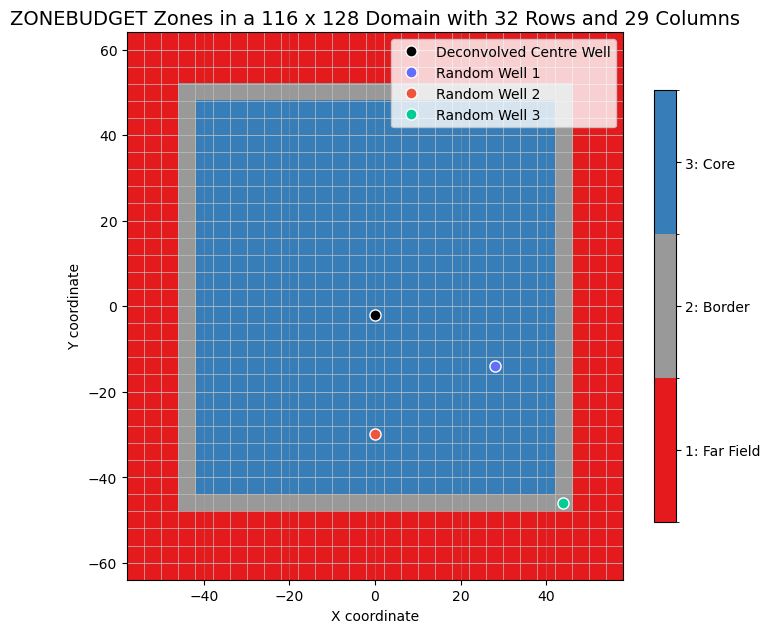

In [9]:
##################################
### visualize ZONEBUDGET zones ###
##################################

cmap = mcolors.ListedColormap(["#e41a1c", "#999999", "#377eb8"])
norm = mcolors.BoundaryNorm([0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(8, 8))

# Use extent to map the [nrow, ncol] array to the [-lx/2, lx/2] space
# Note: MODFLOW rows go top-to-bottom, so we flip the y-extent or the array
im = ax.imshow(zon[0], 
               extent=[grid.extent[0], grid.extent[1], grid.extent[2], grid.extent[3]], 
               cmap=cmap, norm=norm, origin='upper', interpolation='nearest')

# plot the centre well
ax.plot(centre_well_x, centre_well_y, 'wo', markersize=8, markeredgecolor='white', color='black', label='Deconvolved Centre Well', zorder=5)

# plot the random wells
colours = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3']
for i, w in enumerate(wells):
    color = colours[i % len(colours)]
    ax.plot(xc[w['r'], w['c']], yc[w['r'], w['c']], 'o', markersize=8, markeredgecolor='white', color=color, label=f"Random Well {i+1}", zorder=5  
    )

# plot model grid lines
for x in x_edges:
    ax.axvline(x=x, color='silver', linewidth=0.5)
for y in y_edges:
    ax.axhline(y=y, color='silver', linewidth=0.5)

# Add grid and labels
ax.set_title(f"ZONEBUDGET Zones in a {int(lx)} x {int(ly)} Domain with {nrow} Rows and {ncol} Columns", fontsize=14)
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.grid(True, alpha=0.3)

# Discrete colorbar
cbar = plt.colorbar(im, ticks=[1, 2, 3], shrink=0.7)
cbar.ax.set_yticklabels(['1: Far Field', '2: Border', '3: Core'])

plt.legend()
plt.show()


In [10]:
##################################
### extract ZONEBUDGET results ###
##################################

# flatten for easier searching
df_r_flat = df_r.reset_index()
df_val_flat = df_val.reset_index()

# extract the fluxes from Zone 2 to Zone 3 for both the random well scenario and the validation scenario
flux_r = df_r_flat[df_r_flat['name'] == 'FROM_ZONE_2']['ZONE_3'].values
flux_val = df_val_flat[df_val_flat['name'] == 'FROM_ZONE_2']['ZONE_3'].values

# prints all non-zero components of the Zone 2 budget as a QC check
z2_budget = df_r_flat[df_r_flat['ZONE_2'] != 0][['name', 'ZONE_2']]
print(z2_budget.groupby('name').sum())

                 ZONE_2
name                   
FROM_ZONE_1  149.466378
STO_SS_IN     39.146095
TO_ZONE_3    188.612503


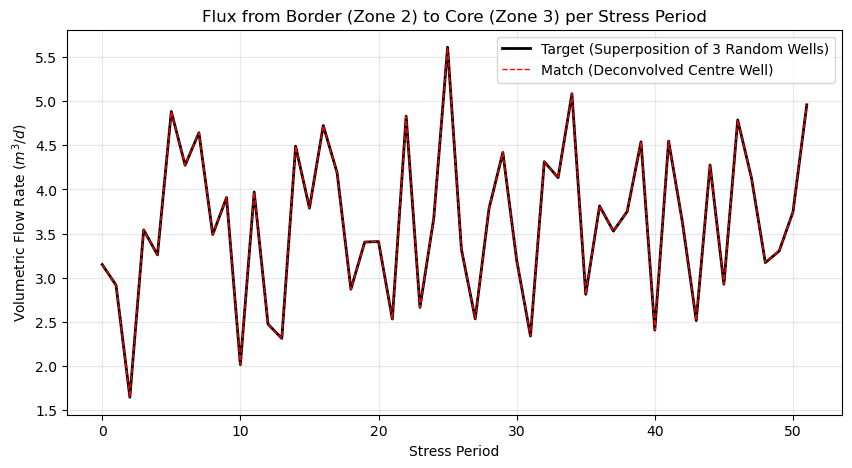

Total Flux (Target): 188.6
Total Flux (Val):    188.6


In [11]:
####################################
### visualize ZONEBUDGET results ###
####################################

plt.figure(figsize=(10, 5))
plt.plot(flux_r, 'k-', label=f'Target (Superposition of {n_wells} Random Wells)', linewidth=2)
plt.plot(flux_val, 'r--', label=f'Match (Deconvolved Centre Well)', linewidth=1)
plt.title('Flux from Border (Zone 2) to Core (Zone 3) per Stress Period')
plt.ylabel('Volumetric Flow Rate ($m^3/d$)')
plt.xlabel('Stress Period')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total Flux (Target): {flux_r.sum():.1f}")
print(f"Total Flux (Val):    {flux_val.sum():.1f}")